# Gas Storage Contract Pricing Model

This notebook implements a pricing model for gas storage contracts with:

- Injection / withdrawal rate constraints  
- Storage capacity limits  
- Daily inventory tracking  
- Market price interpolation  
- Full cashflow valuation  

The model is designed as a prototype for desk-level pricing and validation before production use.

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
from typing import List, Dict, Union

In [5]:
price_data = pd.read_csv('nat_gas.csv')

price_data.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


<Axes: title={'center': 'Natural Gas Prices'}, xlabel='Dates'>

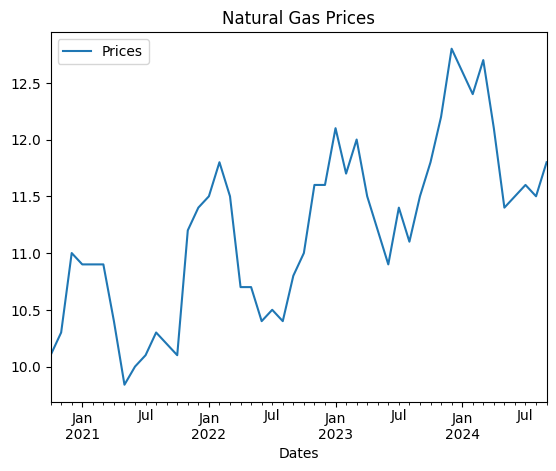

In [7]:
price_data['Dates'] = pd.to_datetime(price_data['Dates'], format="%m/%d/%y")
price_data['Prices'] = pd.to_numeric(price_data['Prices'])

price_data = price_data.sort_values('Dates')

price_data.plot(x='Dates', y='Prices', title="Natural Gas Prices")

In [9]:
def get_price_on_date(price_df, target_date):
    exact = price_df[price_df['Dates'] == target_date]
    if not exact.empty:
        return float(exact.iloc[0]['Prices'])

    before = price_df[price_df['Dates'] <= target_date]
    after = price_df[price_df['Dates'] >= target_date]

    if before.empty:
        return float(price_df.iloc[0]['Prices'])
    if after.empty:
        return float(price_df.iloc[-1]['Prices'])

    d0 = before.iloc[-1]['Dates']
    d1 = after.iloc[0]['Dates']

    p0 = float(before.iloc[-1]['Prices'])
    p1 = float(after.iloc[0]['Prices'])

    if d1 == d0:
        return p0

    t = (target_date - d0).days / (d1 - d0).days
    return p0 + t * (p1 - p0)


def price_storage_contract(injection_schedule,
                           withdrawal_schedule,
                           price_data,
                           max_storage_volume,
                           storage_cost_per_unit,
                           date_format="%m/%d/%y"):

    price_df = price_data.copy()

    price_df['Dates'] = pd.to_datetime(price_df['Dates'])
    price_df = price_df.sort_values('Dates')

    events = []
    total_injection_cost = 0
    total_withdrawal_revenue = 0

    # injections
    for inj in injection_schedule:
        d = pd.to_datetime(inj['date'], format=date_format)
        v = inj['volume']
        p = get_price_on_date(price_df, d)

        total_injection_cost += p * v
        events.append((d, "inject", v, p, -p*v))

    # withdrawals
    for wd in withdrawal_schedule:
        d = pd.to_datetime(wd['date'], format=date_format)
        v = wd['volume']
        p = get_price_on_date(price_df, d)

        total_withdrawal_revenue += p * v
        events.append((d, "withdraw", v, p, p*v))

    events.sort(key=lambda x: x[0])

    # inventory + storage cost
    inventory = 0
    storage_cost = 0

    for i in range(len(events)):
        d, t, v, p, cf = events[i]

        if t == "inject":
            inventory += v
        else:
            inventory -= v

        if i < len(events) - 1:
            days = (events[i+1][0] - d).days
        else:
            days = 0

        storage_cost += inventory * storage_cost_per_unit * days

    net_value = total_withdrawal_revenue - total_injection_cost - storage_cost

    return {
        "contract_value": net_value,
        "injection_cost": total_injection_cost,
        "withdrawal_revenue": total_withdrawal_revenue,
        "storage_cost": storage_cost,
        "events": events
    }

In [11]:
result = price_storage_contract(
    injection_schedule=[{"date": "5/31/21", "volume": 500000}],
    withdrawal_schedule=[{"date": "1/31/22", "volume": 500000}],
    price_data=price_data,
    max_storage_volume=1_000_000,
    storage_cost_per_unit=0.01
)

result

{'contract_value': -395000.0,
 'injection_cost': 4920000.0,
 'withdrawal_revenue': 5750000.0,
 'storage_cost': 1225000.0,
 'events': [(Timestamp('2021-05-31 00:00:00'),
   'inject',
   500000,
   9.84,
   -4920000.0),
  (Timestamp('2022-01-31 00:00:00'), 'withdraw', 500000, 11.5, 5750000.0)]}

In [13]:
print("Contract Value:", result["contract_value"])
print("Injection Cost:", result["injection_cost"])
print("Withdrawal Revenue:", result["withdrawal_revenue"])
print("Storage Cost:", result["storage_cost"])

Contract Value: -395000.0
Injection Cost: 4920000.0
Withdrawal Revenue: 5750000.0
Storage Cost: 1225000.0


In [15]:
import pandas as pd

df_events = pd.DataFrame(result["events"],
                         columns=["Date", "Type", "Volume", "Price", "Cashflow"])

df_events

,Date,Type,Volume,Price,Cashflow
0,2021-05-31,inject,500000,9.84,-4920000.0
1,2022-01-31,withdraw,500000,11.50,5750000.0


In [16]:
scenarios = [
    (
        [{"date": "5/31/21", "volume": 300000}],
        [{"date": "12/31/21", "volume": 300000}]
    ),
    (
        [{"date": "9/30/21", "volume": 500000}],
        [{"date": "2/28/22", "volume": 500000}]
    )
]

for i, (inj, wd) in enumerate(scenarios):
    res = price_storage_contract(
        inj, wd, price_data, 1_000_000, 0.01
    )
    print(f"Scenario {i+1}: {res['contract_value']:.2f}")

Scenario 1: -174000.00
Scenario 2: 45000.00
